In [ ]:
import tensorflow as tf
import cv2
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from google.colab import drive
drive.mount('/content/drive')
from tensorflow.keras.preprocessing.image import ImageDataGenerator

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
data_uas = ('/content/drive/MyDrive/Colab Notebooks/DatasetPandu/dataset')

In [ ]:
data = tf.keras.utils.image_dataset_from_directory(data_uas, image_size=(224, 224), batch_size=16)
print(data.class_names)
class_names = data.class_names

Found 300 files belonging to 3 classes.
['boots', 'heels', 'sneaker']


In [ ]:
data_iterator = data.as_numpy_iterator()
print("data_iterator", data_iterator)

data_iterator <tensorflow.python.data.ops.dataset_ops.NumpyIterator object at 0x7d8e00639500>


In [ ]:
batch = data_iterator.next()
print("batch", batch)

batch (array([[[[254.     , 254.     , 254.     ],
         [254.     , 254.     , 254.     ],
         [254.     , 254.     , 254.     ],
         ...,
         [254.     , 254.     , 254.     ],
         [254.     , 254.     , 254.     ],
         [254.     , 254.     , 254.     ]],

        [[254.     , 254.     , 254.     ],
         [254.     , 254.     , 254.     ],
         [254.     , 254.     , 254.     ],
         ...,
         [254.     , 254.     , 254.     ],
         [254.     , 254.     , 254.     ],
         [254.     , 254.     , 254.     ]],

        [[254.     , 254.     , 254.     ],
         [254.     , 254.     , 254.     ],
         [254.     , 254.     , 254.     ],
         ...,
         [254.     , 254.     , 254.     ],
         [254.     , 254.     , 254.     ],
         [254.     , 254.     , 254.     ]],

        ...,

        [[254.     , 254.     , 254.     ],
         [254.     , 254.     , 254.     ],
         [254.     , 254.     , 254.     ],
       

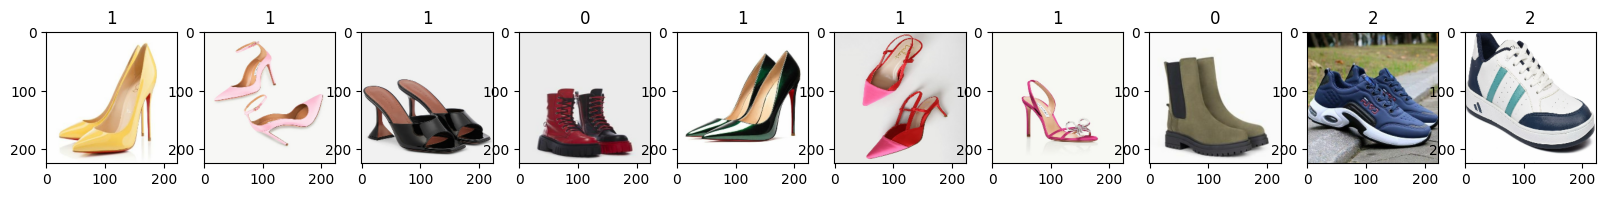

In [ ]:
fig, ax = plt.subplots(ncols=10, figsize=(20,20))
for idx, img in enumerate(batch[0][:10]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(batch[1][idx])

In [ ]:
data = data.map(lambda x, y: (x/255.0, y))
print("Data type after normalization: {}".format(data.element_spec))
print("Data shape after normalization: {}".format(data.element_spec))
print("Jumlah data", len(data))

Data type after normalization: (TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))
Data shape after normalization: (TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))
Jumlah data 19


In [ ]:
train_size = int(len(data)* 0.8)
val_size = int(len(data) * 0.1)
test_size = int(len(data)* 0.1)

print(train_size)
print(val_size)
print(test_size)

train = data.take(train_size)
val = data.skip(train_size).take(val_size)
test = data.skip(train_size+val_size).take(test_size)

15
1
1


In [ ]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications.resnet50 import preprocess_input, decode_predictions
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Conv2D, MaxPooling2D


model_Resnet50Arch = Sequential()

model_Resnet50Arch.add(Conv2D(96, kernel_size=(11, 11), strides=4, activation='relu', input_shape=(224, 224, 3)))
model_Resnet50Arch.add(MaxPooling2D(pool_size=(3, 3), strides=2))
model_Resnet50Arch.add(Conv2D(256, kernel_size=(5, 5), strides=1, activation='relu'))
model_Resnet50Arch.add(MaxPooling2D(pool_size=(3, 3), strides=2))

model_Resnet50Arch.add(Conv2D(384, kernel_size=(3, 3), strides=1, activation='relu'))
model_Resnet50Arch.add(Conv2D(384, kernel_size=(3, 3), strides=1, activation='relu'))
model_Resnet50Arch.add(Conv2D(256, kernel_size=(3, 3), strides=1, activation='relu'))
model_Resnet50Arch.add(MaxPooling2D(pool_size=(3, 3), strides=2))

model_Resnet50Arch.add(GlobalAveragePooling2D())
model_Resnet50Arch.add(Dense(256, activation='relu'))
model_Resnet50Arch.add(Dropout(0.5))
model_Resnet50Arch.add(Dense(4096, activation='relu'))
model_Resnet50Arch.add(Dropout(0.5))
model_Resnet50Arch.add(Dense(5, activation='softmax'))

model_Resnet50Arch.compile(optimizer=Adam(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_Resnet50Arch.summary()

Model: "sequential_8"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_40 (Conv2D)          (None, 54, 54, 96)        34944     
                                                                 
 max_pooling2d_24 (MaxPooli  (None, 26, 26, 96)        0         
 ng2D)                                                           
                                                                 
 conv2d_41 (Conv2D)          (None, 22, 22, 256)       614656    
                                                                 
 max_pooling2d_25 (MaxPooli  (None, 10, 10, 256)       0         
 ng2D)                                                           
                                                                 
 conv2d_42 (Conv2D)          (None, 8, 8, 384)         885120    
                                                                 
 conv2d_43 (Conv2D)          (None, 6, 6, 384)        

In [ ]:
history = model_Resnet50Arch.fit(train, epochs=100, validation_data=val)

Epoch 1/100
15/15 [==============================] - 5s 118ms/step - loss: 1.3536 - accuracy: 0.2833 - val_loss: 1.1271 - val_accuracy: 0.1875
Epoch 2/100
15/15 [==============================] - 2s 127ms/step - loss: 1.1465 - accuracy: 0.3125 - val_loss: 1.1340 - val_accuracy: 0.1875
Epoch 3/100
15/15 [==============================] - 2s 124ms/step - loss: 1.0963 - accuracy: 0.3750 - val_loss: 1.0213 - val_accuracy: 0.5000
Epoch 4/100
15/15 [==============================] - 3s 182ms/step - loss: 1.1525 - accuracy: 0.3333 - val_loss: 1.1420 - val_accuracy: 0.2500
Epoch 5/100
15/15 [==============================] - 2s 123ms/step - loss: 1.1349 - accuracy: 0.3250 - val_loss: 1.1300 - val_accuracy: 0.1250
Epoch 6/100
15/15 [==============================] - 3s 146ms/step - loss: 1.1142 - accuracy: 0.3583 - val_loss: 1.0984 - val_accuracy: 0.3125
Epoch 7/100
15/15 [==============================] - 2s 144ms/step - loss: 1.1190 - accuracy: 0.3292 - val_loss: 1.1153 - val_accuracy: 0.1875

<function matplotlib.pyplot.show(close=None, block=None)>

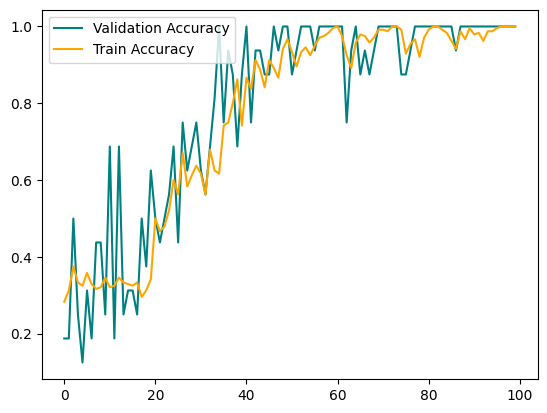

In [ ]:
fig = plt.figure()
plt.plot(history.history['val_accuracy'],color='teal',label = 'Validation Accuracy')
plt.plot(history.history['accuracy'],color='orange',label='Train Accuracy')
plt.legend(loc="upper left")
plt.show

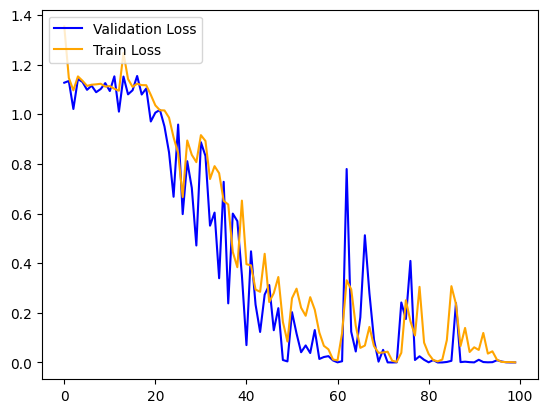

In [ ]:
fig = plt.figure()
plt.plot(history.history['val_loss'],color='blue', label='Validation Loss')
plt.plot(history.history['loss'],color='orange', label='Train Loss')
plt.legend(loc="upper left")
plt.show()

In [ ]:
model_Resnet50Arch.evaluate(test)

1/1 [==============================] - 1s 1s/step - loss: 4.4181e-06 - accuracy: 1.0000


[4.418116986926179e-06, 1.0]

In [ ]:
model_Resnet50Arch.save('/content/drive/MyDrive/Colab Notebooks/DatasetPandu/hasil/model_ArchResNet.h5')